# Basic Momentum Research

This notebook tests a deliberately simple momentum signal:

`signal = mean(previous returns) / volatility(previous returns)`

Asset selection is based only on the first 400 days. The last 100 days are shown only as an out-of-sample sanity check.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
assets = list(prices.columns)

TRAIN_END = 400
TEST_START = 400
LOOKBACK = 20

DEFAULT_POSITION_LIMIT = 10_000
SPECIAL_POSITION_LIMIT = 100_000
DEFAULT_COMMISSION = 0.0001
SPECIAL_COMMISSION = 0.00002

position_limits = pd.Series(DEFAULT_POSITION_LIMIT, index=assets, dtype=float)
position_limits.iloc[0] = SPECIAL_POSITION_LIMIT

commission_rates = pd.Series(DEFAULT_COMMISSION, index=assets, dtype=float)
commission_rates.iloc[0] = SPECIAL_COMMISSION

returns = prices.pct_change()
prices.head()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


## Build The Basic Signal

The signal uses only information available before trading. For day `t`, it uses returns up to day `t-1`.

In [8]:
def make_basic_momentum_signal(returns, lookback=20):
    past_returns = returns.shift(1)
    rolling_mean = past_returns.rolling(lookback).mean()
    rolling_vol = past_returns.rolling(lookback).std()
    raw_signal = rolling_mean / rolling_vol.replace(0, np.nan)
    return raw_signal.replace([np.inf, -np.inf], np.nan).fillna(0.0)


signal = make_basic_momentum_signal(returns, LOOKBACK)
signal.tail()


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
495,-0.128145,0.251008,-0.179351,-0.259087,-0.048683,0.136678,0.229947,-0.476824,0.034917,0.056182,...,0.044704,0.080407,-0.103700,0.154890,-0.123372,-0.080317,0.014192,-0.172633,-0.392489,-0.138493
496,-0.078510,0.322314,-0.110378,-0.086745,-0.028622,0.162893,0.340061,-0.407780,0.091378,0.120115,...,-0.029987,0.156334,-0.139050,0.333072,-0.090017,-0.098281,0.177633,-0.120911,-0.289611,-0.160099
497,-0.013388,0.429023,-0.096210,-0.025412,-0.106967,0.311405,0.334495,-0.270554,0.037459,0.208953,...,0.018748,0.121765,-0.049488,0.317826,0.060646,0.020641,0.317371,-0.029457,-0.211293,-0.112515
498,-0.024315,0.406313,-0.087351,0.062238,0.010220,0.281317,0.256396,-0.136520,0.115705,0.172491,...,0.026556,0.116852,0.050494,0.237503,0.011175,0.060747,0.328052,0.037838,-0.232181,-0.250788
499,0.066400,0.398776,-0.014893,0.142303,0.083853,0.372164,0.389975,-0.031678,0.055367,0.229150,...,0.121360,0.227436,0.198143,0.297389,0.091653,0.000908,0.352622,0.118532,-0.149203,-0.181509


## Backtest Helpers

In [9]:
def score_function(mean_pl, std_pl):
    if mean_pl <= 0 or std_pl < 1e-10:
        return mean_pl
    sharpe = np.sqrt(250) * mean_pl / std_pl
    return mean_pl * (sharpe**2 / (sharpe**2 + 1))


def performance_summary(daily_pl):
    daily_pl = pd.Series(daily_pl).dropna()
    mean_pl = daily_pl.mean()
    std_pl = daily_pl.std(ddof=0)
    sharpe = 0.0 if std_pl <= 0 else np.sqrt(250) * mean_pl / std_pl
    return pd.Series({
        "mean_pl": mean_pl,
        "std_pl": std_pl,
        "annualised_sharpe": sharpe,
        "score": score_function(mean_pl, std_pl),
        "total_pl": daily_pl.sum(),
    })


def signal_to_dollar_targets(signal_frame, selected_assets=None):
    if selected_assets is None:
        selected_assets = list(signal_frame.columns)

    selected_signal = signal_frame[selected_assets].copy()
    gross_signal = selected_signal.abs().sum(axis=1).replace(0, np.nan)
    weights = selected_signal.div(gross_signal, axis=0).fillna(0.0)

    targets = pd.DataFrame(0.0, index=signal_frame.index, columns=signal_frame.columns)
    targets[selected_assets] = weights * position_limits[selected_assets]
    return targets.clip(lower=-position_limits, upper=position_limits, axis=1)


def backtest_dollar_targets(dollar_targets, start_day, end_day):
    share_targets = (dollar_targets / prices).replace([np.inf, -np.inf], np.nan).fillna(0).astype(int)

    cash = 0.0
    current_position = pd.Series(0.0, index=assets)
    portfolio_value = 0.0
    daily_pl = []
    daily_values = []
    total_dollar_volume = 0.0

    for t in range(start_day, end_day + 1):
        current_prices = prices.iloc[t]

        if t < end_day:
            new_position = share_targets.iloc[t].astype(float)
        else:
            new_position = current_position.copy()

        trade = new_position - current_position
        traded_dollars = current_prices * trade.abs()
        commission = (traded_dollars * commission_rates).sum()
        total_dollar_volume += traded_dollars.sum()

        cash -= current_prices.dot(trade) + commission
        current_position = new_position

        new_value = cash + current_position.dot(current_prices)
        if t > start_day:
            daily_pl.append(new_value - portfolio_value)
            daily_values.append(new_value)
        portfolio_value = new_value

    index = prices.index[start_day + 1:end_day + 1]
    return {
        "daily_pl": pd.Series(daily_pl, index=index, name="daily_pl"),
        "daily_values": pd.Series(daily_values, index=index, name="value"),
        "total_dollar_volume": total_dollar_volume,
        "final_value": portfolio_value,
    }

## Train-Only Asset Selection

Each asset is tested on its own over days `LOOKBACK + 1` to `399`. We keep only assets with positive training Sharpe.

In [10]:
asset_rows = []

for asset in assets:
    asset_targets = pd.DataFrame(0.0, index=prices.index, columns=assets)
    asset_signal = signal[asset]
    asset_targets[asset] = np.tanh(asset_signal) * position_limits[asset]

    train_result = backtest_dollar_targets(asset_targets, start_day=LOOKBACK + 1, end_day=TRAIN_END - 1)
    test_result = backtest_dollar_targets(asset_targets, start_day=TEST_START, end_day=len(prices) - 1)

    train_summary = performance_summary(train_result["daily_pl"])
    test_summary = performance_summary(test_result["daily_pl"])

    asset_rows.append({
        "asset": asset,
        "train_sharpe": train_summary["annualised_sharpe"],
        "train_mean_pl": train_summary["mean_pl"],
        "train_score": train_summary["score"],
        "test_sharpe": test_summary["annualised_sharpe"],
        "test_mean_pl": test_summary["mean_pl"],
        "test_score": test_summary["score"],
    })

asset_table = pd.DataFrame(asset_rows).sort_values("train_sharpe", ascending=False).reset_index(drop=True)
good_assets = asset_table.loc[asset_table["train_sharpe"] > 0, "asset"].tolist()

print(f"Selected {len(good_assets)} / {len(assets)} assets with positive training Sharpe")
print(good_assets)
display(asset_table)

Selected 12 / 51 assets with positive training Sharpe
['SRNA', 'NPCK', 'HRET', 'HRND', 'ILVX', 'MMBT', 'HETT', 'FARS', 'DUCT', 'MDGI', 'HUXZ', 'NGTE']


,asset,train_sharpe,train_mean_pl,train_score,test_sharpe,test_mean_pl,test_score
0,SRNA,2.325234,7.022612,5.926478,1.389502,3.537122,2.330207
1,NPCK,1.046753,3.559493,1.861011,0.547592,0.988230,0.227969
2,HRET,0.670543,2.034942,0.631173,-1.017788,-2.340169,-2.340169
3,HRND,0.538852,2.261270,0.508839,0.565544,2.334968,0.565838
4,ILVX,0.510942,1.103053,0.228351,2.385138,6.363443,5.412097
5,MMBT,0.458643,2.729703,0.474408,-2.226886,-7.365990,-7.365990
6,HETT,0.393866,0.927103,0.124507,1.340697,3.127223,2.009346
7,FARS,0.288549,0.654510,0.050306,-0.515282,-0.970981,-0.970981
8,DUCT,0.093367,0.279795,0.002418,0.170061,0.409944,0.011523
9,MDGI,0.081339,0.209694,0.001378,-0.755306,-1.748803,-1.748803


## Strict Training-Sharpe Threshold Sweep

The table below keeps only assets whose individual training Sharpe is above each cutoff. The cutoff is chosen using training data only; the last-100-day columns are just a sanity check.

In [11]:
threshold_rows = []
thresholds = [0.0, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00]

for threshold in thresholds:
    threshold_assets = asset_table.loc[asset_table["train_sharpe"] > threshold, "asset"].tolist()
    if not threshold_assets:
        continue

    threshold_targets = signal_to_dollar_targets(signal, selected_assets=threshold_assets)
    threshold_train = backtest_dollar_targets(threshold_targets, start_day=LOOKBACK + 1, end_day=TRAIN_END - 1)
    threshold_test = backtest_dollar_targets(threshold_targets, start_day=TEST_START, end_day=len(prices) - 1)

    train_summary = performance_summary(threshold_train["daily_pl"])
    test_summary = performance_summary(threshold_test["daily_pl"])

    threshold_rows.append({
        "threshold": threshold,
        "n_assets": len(threshold_assets),
        "assets": threshold_assets,
        "train_sharpe": train_summary["annualised_sharpe"],
        "train_score": train_summary["score"],
        "test_sharpe": test_summary["annualised_sharpe"],
        "test_score": test_summary["score"],
        "test_total_pl": test_summary["total_pl"],
    })

threshold_table = pd.DataFrame(threshold_rows).sort_values("threshold").reset_index(drop=True)
display(threshold_table.drop(columns=["assets"]))

best_threshold_row = threshold_table.sort_values("train_sharpe", ascending=False).iloc[0]
strict_assets = best_threshold_row["assets"]

print("Best threshold by training Sharpe:", best_threshold_row["threshold"])
print(f"Selected {len(strict_assets)} assets:")
print(strict_assets)

,threshold,n_assets,train_sharpe,train_score,test_sharpe,test_score,test_total_pl
0,0.00,12,1.808281,7.734714,0.718869,1.333380,387.444798
1,0.25,8,1.704435,8.590775,0.786576,1.843256,477.426230
2,0.50,5,1.859635,10.663249,1.328513,5.936964,920.777480
3,0.75,2,1.677863,10.848015,1.335026,7.162406,1106.923551
4,1.00,2,1.677863,10.848015,1.335026,7.162406,1106.923551
5,1.25,1,1.634208,11.901298,1.424473,9.263529,1369.052969
6,1.50,1,1.634208,11.901298,1.424473,9.263529,1369.052969
7,2.00,1,1.634208,11.901298,1.424473,9.263529,1369.052969


Best threshold by training Sharpe: 0.5
Selected 5 assets:
['SRNA', 'NPCK', 'HRET', 'HRND', 'ILVX']


## Portfolio Using Only Good Training Assets

In [12]:
all_asset_targets = signal_to_dollar_targets(signal, selected_assets=assets)
selected_asset_targets = signal_to_dollar_targets(signal, selected_assets=good_assets)
strict_asset_targets = signal_to_dollar_targets(signal, selected_assets=strict_assets)

all_train = backtest_dollar_targets(all_asset_targets, start_day=LOOKBACK + 1, end_day=TRAIN_END - 1)
selected_train = backtest_dollar_targets(selected_asset_targets, start_day=LOOKBACK + 1, end_day=TRAIN_END - 1)
strict_train = backtest_dollar_targets(strict_asset_targets, start_day=LOOKBACK + 1, end_day=TRAIN_END - 1)

all_test = backtest_dollar_targets(all_asset_targets, start_day=TEST_START, end_day=len(prices) - 1)
selected_test = backtest_dollar_targets(selected_asset_targets, start_day=TEST_START, end_day=len(prices) - 1)
strict_test = backtest_dollar_targets(strict_asset_targets, start_day=TEST_START, end_day=len(prices) - 1)

summary = pd.DataFrame({
    "all_assets_train": performance_summary(all_train["daily_pl"]),
    "selected_assets_train": performance_summary(selected_train["daily_pl"]),
    "strict_assets_train": performance_summary(strict_train["daily_pl"]),
    "all_assets_test": performance_summary(all_test["daily_pl"]),
    "selected_assets_test": performance_summary(selected_test["daily_pl"]),
    "strict_assets_test": performance_summary(strict_test["daily_pl"]),
})

display(summary)

,all_assets_train,selected_assets_train,strict_assets_train,all_assets_test,selected_assets_test,strict_assets_test
mean_pl,-7.758373,10.100157,13.746679,-6.086286,3.913584,9.300783
std_pl,69.732689,88.314567,116.879954,63.926112,86.078495,110.693872
annualised_sharpe,-1.759156,1.808281,1.859635,-1.505373,0.718869,1.328513
score,-7.758373,7.734714,10.663249,-6.086286,1.333380,5.936964
total_pl,-2932.664944,3817.859525,5196.244516,-602.542350,387.444798,920.777480


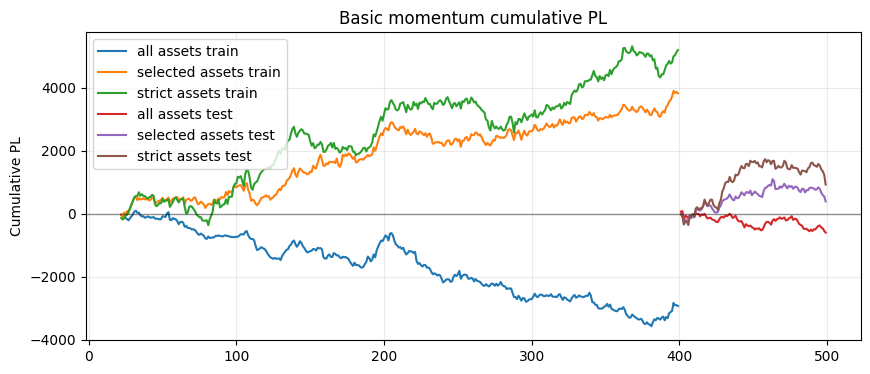

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
all_train["daily_pl"].cumsum().plot(ax=ax, label="all assets train")
selected_train["daily_pl"].cumsum().plot(ax=ax, label="selected assets train")
strict_train["daily_pl"].cumsum().plot(ax=ax, label="strict assets train")
all_test["daily_pl"].cumsum().plot(ax=ax, label="all assets test")
selected_test["daily_pl"].cumsum().plot(ax=ax, label="selected assets test")
strict_test["daily_pl"].cumsum().plot(ax=ax, label="strict assets test")
ax.axhline(0, color="black", linewidth=1, alpha=0.4)
ax.set_title("Basic momentum cumulative PL")
ax.set_ylabel("Cumulative PL")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()